Dataset loaded successfully!

First 5 rows:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1



Dataset Shape:
(768, 9)

Column Names:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

Missing Values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

========== STATISTICAL VALUES ==========

Glucose:
Mean = 120.89
Standard Deviation = 31.97

BMI:
Mean = 31.99
Standard Deviation = 7.88


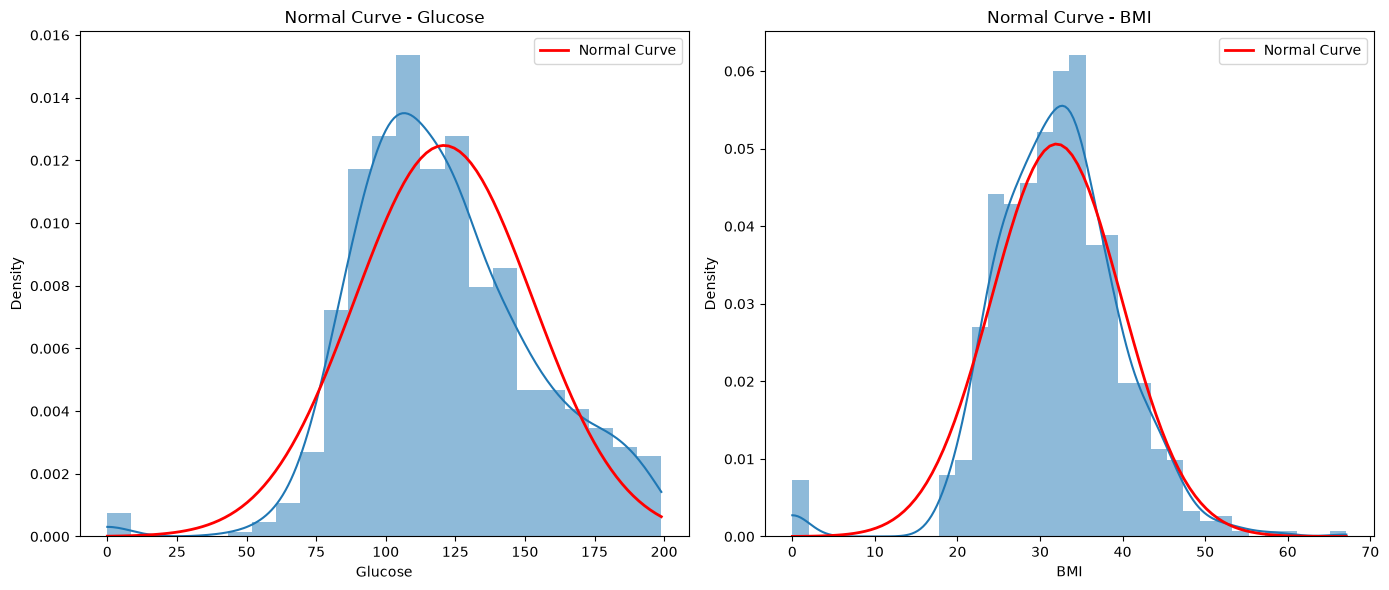

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

# Display plots in Jupyter
%matplotlib inline

# ==========================================
# LOAD PIMA INDIANS DIABETES DATASET
# ==========================================

file_name = "pima-indians-diabetes.data.txt"

columns = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
    "Outcome"
]

uci_diabetes = pd.read_csv(
    file_name,
    header=None,
    names=columns
)

print("Dataset loaded successfully!")

# ==========================================
# DISPLAY DATASET
# ==========================================

print("\nFirst 5 rows:")
display(uci_diabetes.head())

print("\nDataset Shape:")
print(uci_diabetes.shape)

print("\nColumn Names:")
print(uci_diabetes.columns.tolist())

# ==========================================
# CHECK MISSING VALUES
# ==========================================

print("\nMissing Values:")
print(uci_diabetes.isnull().sum())

# ==========================================
# SELECT GLUCOSE AND BMI
# ==========================================

glucose = uci_diabetes["Glucose"].dropna()
bmi = uci_diabetes["BMI"].dropna()

# ==========================================
# CALCULATE MEAN AND STANDARD DEVIATION
# ==========================================

glucose_mean = glucose.mean()
glucose_std = glucose.std()

bmi_mean = bmi.mean()
bmi_std = bmi.std()

print("\n========== STATISTICAL VALUES ==========")

print("\nGlucose:")
print("Mean =", round(glucose_mean, 2))
print("Standard Deviation =", round(glucose_std, 2))

print("\nBMI:")
print("Mean =", round(bmi_mean, 2))
print("Standard Deviation =", round(bmi_std, 2))

# ==========================================
# PLOT NORMAL CURVES
# ==========================================

plt.figure(figsize=(14, 6))

# ------------------------------------------
# GLUCOSE NORMAL CURVE
# ------------------------------------------

plt.subplot(1, 2, 1)

sns.histplot(
    glucose,
    kde=True,
    stat="density",
    linewidth=0
)

x_glucose = np.linspace(
    glucose.min(),
    glucose.max(),
    100
)

normal_glucose = norm.pdf(
    x_glucose,
    glucose_mean,
    glucose_std
)

plt.plot(
    x_glucose,
    normal_glucose,
    'r',
    linewidth=2,
    label="Normal Curve"
)

plt.title("Normal Curve - Glucose")
plt.xlabel("Glucose")
plt.ylabel("Density")
plt.legend()

# ------------------------------------------
# BMI NORMAL CURVE
# ------------------------------------------

plt.subplot(1, 2, 2)

sns.histplot(
    bmi,
    kde=True,
    stat="density",
    linewidth=0
)

x_bmi = np.linspace(
    bmi.min(),
    bmi.max(),
    100
)

normal_bmi = norm.pdf(
    x_bmi,
    bmi_mean,
    bmi_std
)

plt.plot(
    x_bmi,
    normal_bmi,
    'r',
    linewidth=2,
    label="Normal Curve"
)

plt.title("Normal Curve - BMI")
plt.xlabel("BMI")
plt.ylabel("Density")
plt.legend()

# ==========================================
# SHOW GRAPH
# ==========================================

plt.tight_layout()
plt.show()

In [2]:
# ============================================
# Z-TEST FOR GLUCOSE
# ============================================

# Import Libraries
import pandas as pd
import numpy as np
from statsmodels.stats.weightstats import ztest

# ============================================
# Load Dataset
# ============================================

file_name = "pima-indians-diabetes.data.txt"

# Column names of Pima Indians Diabetes Dataset
columns = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
    "Outcome"
]

# Read the .txt dataset
uci_diabetes = pd.read_csv(
    file_name,
    header=None,
    names=columns
)

print("Dataset loaded successfully!")

# ============================================
# Display First 5 Rows
# ============================================

print("\nFirst 5 rows of the dataset:")
display(uci_diabetes.head())

# ============================================
# Perform Z-Test
# ============================================

# H0: Mean Glucose = 100
# H1: Mean Glucose != 100

z_stat, p_value = ztest(
    uci_diabetes["Glucose"],
    value=100
)

# ============================================
# Display Results
# ============================================

print("\n========== Z-TEST RESULTS ==========")
print(f"Z-Statistic: {z_stat:.4f}")
print(f"P-Value: {p_value:.4f}")

# ============================================
# Interpretation
# ============================================

alpha = 0.05

print("\n========== INTERPRETATION ==========")

if p_value < alpha:
    print("Reject the null hypothesis.")
    print("The mean Glucose level is significantly different from 100.")
else:
    print("Fail to reject the null hypothesis.")
    print("There is no significant difference in the mean Glucose level from 100.")

Dataset loaded successfully!

First 5 rows of the dataset:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1



========== Z-TEST RESULTS ==========
Z-Statistic: 18.1107
P-Value: 0.0000

========== INTERPRETATION ==========
Reject the null hypothesis.
The mean Glucose level is significantly different from 100.


In [3]:
# ============================================
# INDEPENDENT TWO-SAMPLE T-TEST
# ============================================

# Import Libraries
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind

# ============================================
# Load Pima Diabetes Dataset
# ============================================

file_name = "pima-indians-diabetes.data.txt"

columns = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
    "Outcome"
]

pima_diabetes = pd.read_csv(
    file_name,
    header=None,
    names=columns
)

print("Dataset loaded successfully!")

# ============================================
# Display First 5 Rows
# ============================================

print("\nFirst 5 rows of the dataset:")
display(pima_diabetes.head())

# ============================================
# Select Numerical Columns
# ============================================

numerical_columns = [
    "Glucose",
    "BloodPressure",
    "BMI"
]

# ============================================
# Split Data into Two Groups
# ============================================
# Group 0 = Non-Diabetic
# Group 1 = Diabetic

group_0 = pima_diabetes[pima_diabetes["Outcome"] == 0]
group_1 = pima_diabetes[pima_diabetes["Outcome"] == 1]

# ============================================
# Perform Independent T-Test
# ============================================

t_test_results = {}

for col in numerical_columns:

    # Remove missing/invalid values
    data_0 = group_0[col].dropna()
    data_1 = group_1[col].dropna()

    # Welch's independent t-test
    t_stat, p_value = ttest_ind(
        data_0,
        data_1,
        equal_var=False
    )

    t_test_results[col] = {
        "T-statistic": t_stat,
        "P-value": p_value
    }

# ============================================
# Convert Results to DataFrame
# ============================================

t_test_df = pd.DataFrame(t_test_results).T

# ============================================
# Display Results
# ============================================

print("\n========== INDEPENDENT T-TEST RESULTS ==========")
print(t_test_df)

# ============================================
# Interpretation
# ============================================

alpha = 0.05

print("\n========== INTERPRETATION ==========")

for col in numerical_columns:

    p_value = t_test_df.loc[col, "P-value"]

    print(f"\n{col}:")

    if p_value < alpha:
        print("Reject the null hypothesis.")
        print(
            f"There is a significant difference in {col} "
            "between diabetic and non-diabetic groups."
        )
    else:
        print("Fail to reject the null hypothesis.")
        print(
            f"There is no significant difference in {col} "
            "between diabetic and non-diabetic groups."
        )

Dataset loaded successfully!

First 5 rows of the dataset:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1



========== INDEPENDENT T-TEST RESULTS ==========
               T-statistic       P-value
Glucose         -13.751537  2.644161e-36
BloodPressure    -1.713087  8.735425e-02
BMI              -8.619317  6.566238e-17

========== INTERPRETATION ==========

Glucose:
Reject the null hypothesis.
There is a significant difference in Glucose between diabetic and non-diabetic groups.

BloodPressure:
Fail to reject the null hypothesis.
There is no significant difference in BloodPressure between diabetic and non-diabetic groups.

BMI:
Reject the null hypothesis.
There is a significant difference in BMI between diabetic and non-diabetic groups.


In [4]:
# ============================================
# ONE-WAY ANOVA TEST
# ============================================

# Import Libraries
import pandas as pd
import numpy as np
from scipy.stats import f_oneway

# ============================================
# Load Pima Diabetes Dataset
# ============================================

file_name = "pima-indians-diabetes.data.txt"

columns = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
    "Outcome"
]

pima_diabetes = pd.read_csv(
    file_name,
    header=None,
    names=columns
)

print("Dataset loaded successfully!")

# ============================================
# Display First 5 Rows
# ============================================

print("\nFirst 5 rows of the dataset:")
display(pima_diabetes.head())

# ============================================
# Select Relevant Numerical Columns
# ============================================

numerical_columns = [
    "Glucose",
    "BloodPressure",
    "BMI"
]

# ============================================
# Create Groups Using Outcome
# ============================================
# Outcome 0 = Non-Diabetic
# Outcome 1 = Diabetic

group_0 = pima_diabetes[pima_diabetes["Outcome"] == 0]
group_1 = pima_diabetes[pima_diabetes["Outcome"] == 1]

# ============================================
# Perform One-Way ANOVA
# ============================================

anova_results = {}

for col in numerical_columns:

    # Remove missing values
    data_0 = group_0[col].dropna()
    data_1 = group_1[col].dropna()

    # Perform One-Way ANOVA
    f_stat, p_value = f_oneway(
        data_0,
        data_1
    )

    anova_results[col] = {
        "F-statistic": f_stat,
        "P-value": p_value
    }

# ============================================
# Convert Results to DataFrame
# ============================================

anova_df = pd.DataFrame(anova_results).T

# ============================================
# Display Results
# ============================================

print("\n========== ONE-WAY ANOVA RESULTS ==========")
print(anova_df)

# ============================================
# Interpretation
# ============================================

alpha = 0.05

print("\n========== INTERPRETATION ==========")

for col in numerical_columns:

    p_value = anova_df.loc[col, "P-value"]

    print(f"\n{col}:")

    if p_value < alpha:
        print("Reject the null hypothesis.")
        print(
            f"There is a significant difference in {col} "
            "between diabetic and non-diabetic groups."
        )
    else:
        print("Fail to reject the null hypothesis.")
        print(
            f"There is no significant difference in {col} "
            "between diabetic and non-diabetic groups."
        )

Dataset loaded successfully!

First 5 rows of the dataset:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1



========== ONE-WAY ANOVA RESULTS ==========
               F-statistic       P-value
Glucose         213.161752  8.935432e-43
BloodPressure     3.256950  7.151390e-02
BMI              71.772072  1.229807e-16

========== INTERPRETATION ==========

Glucose:
Reject the null hypothesis.
There is a significant difference in Glucose between diabetic and non-diabetic groups.

BloodPressure:
Fail to reject the null hypothesis.
There is no significant difference in BloodPressure between diabetic and non-diabetic groups.

BMI:
Reject the null hypothesis.
There is a significant difference in BMI between diabetic and non-diabetic groups.
